# Baseline: Historical Average
Per-station mean demand grouped by hour-of-day and day-of-week, computed on the training split only.
This serves as a naive baseline to compare against the GCN+GRU models.

In [8]:
from google.colab import drive
drive.mount('/content/drive')
import os

WORK_DIR = '/content/drive/MyDrive/DL_Project'
os.chdir(WORK_DIR)
print('cwd:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cwd: /content/drive/.shortcut-targets-by-id/1cv6g42seKHWos13nKtt695z3yVVUNFOn/DL_Project


In [10]:
import polars as pl
import numpy as np
from scipy.stats import pearsonr

# Data Prep

In [11]:
df = pl.read_parquet('data/cabi_master.parquet').with_columns([
    pl.col('start_station_id').cast(pl.Int64)
])

# same station filter as GCN models
min_rows = 1000
station_counts = df.group_by('start_station_id').agg(pl.len().alias('n_rows')).filter(pl.col('n_rows') >= min_rows)
valid_stations = set(station_counts['start_station_id'].to_list())
df = df.filter(pl.col('start_station_id').is_in(valid_stations))

print(f'Stations: {df["start_station_id"].n_unique()}')
print(f'Rows: {len(df):,}')

Stations: 407
Rows: 15,447,920


# Train / Test Split
Same sequential 70/15/15 split as the GCN models — fit the historical average only on training timesteps.

In [12]:
distinct_timesteps = (
    df.select('started_at_15')
    .unique()
    .sort('started_at_15')
    .get_column('started_at_15')
    .to_list()
)
T = len(distinct_timesteps)
train_end = int(T * 0.70)
val_end   = int(T * 0.85)

train_cutoff = distinct_timesteps[train_end]
val_cutoff   = distinct_timesteps[val_end]

train_df = df.filter(pl.col('started_at_15') <  train_cutoff)
val_df   = df.filter((pl.col('started_at_15') >= train_cutoff) & (pl.col('started_at_15') < val_cutoff))
test_df  = df.filter(pl.col('started_at_15') >= val_cutoff)

print(f'Train rows: {len(train_df):,}')
print(f'Val rows:   {len(val_df):,}')
print(f'Test rows:  {len(test_df):,}')

Train rows: 10,381,828
Val rows:   2,556,677
Test rows:  2,509,415


# Compute Historical Averages
Group training data by (station, hour, day_of_week) and take mean demand.
This is our entire "model" — a lookup table.

In [13]:
# extract hour and day_of_week from timestamp
train_df = train_df.with_columns([
    pl.col('started_at_15').dt.hour().alias('hour'),
    pl.col('started_at_15').dt.weekday().alias('day_of_week'),
])

lookup = (
    train_df
    .group_by(['start_station_id', 'hour', 'day_of_week'])
    .agg(pl.col('demand').mean().alias('pred_demand'))
)

global_mean = train_df['demand'].mean()
print(f'Lookup table size: {len(lookup):,} (station x hour x dow combos)')
print(f'Global mean demand (fallback): {global_mean:.4f}')

Lookup table size: 63,939 (station x hour x dow combos)
Global mean demand (fallback): -0.0050


# Evaluate on Test Set

In [14]:
test_df = test_df.with_columns([
    pl.col('started_at_15').dt.hour().alias('hour'),
    pl.col('started_at_15').dt.weekday().alias('day_of_week'),
])

test_pred = test_df.join(lookup, on=['start_station_id', 'hour', 'day_of_week'], how='left')
test_pred = test_pred.with_columns(pl.col('pred_demand').fill_null(global_mean))

targets = test_pred['demand'].to_numpy().astype(np.float32)
preds   = test_pred['pred_demand'].to_numpy().astype(np.float32)

nz       = targets != 0
mae_all  = np.abs(preds - targets).mean()
mae_nz   = np.abs(preds[nz] - targets[nz]).mean()
rmse_all = np.sqrt(((preds - targets) ** 2).mean())
pcp_all  = (preds.round() == targets).mean()
pcp_nz   = (preds[nz].round() == targets[nz]).mean()

actual_trip    = targets != 0
predicted_trip = preds.round() != 0
pptt = (predicted_trip == actual_trip).mean()

print(f'Test rows evaluated: {len(targets):,}')
print(f'MAE  (all):      {mae_all:.4f}')
print(f'MAE  (nonzero):  {mae_nz:.4f}')
print(f'RMSE (all):      {rmse_all:.4f}')
print(f'PCP  (all):      {pcp_all:.4f}')
print(f'PCP  (nonzero):  {pcp_nz:.4f}')
print(f'PPTT:            {pptt:.4f}')

if nz.sum() > 10:
    corr, _ = pearsonr(preds[nz], targets[nz])
    print(f'Corr (nonzero):  {corr:.4f}')

Test rows evaluated: 2,509,415
MAE  (all):      1.1853
MAE  (nonzero):  1.3142
RMSE (all):      1.5077
PCP  (all):      0.2061
PCP  (nonzero):  0.1178
PPTT:            0.3199
Corr (nonzero):  0.3257


# Evaluate on Val Set

In [15]:
import os
import numpy as np
import pandas as pd

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

# ---- compute metrics ----
val_df = val_df.with_columns([
    pl.col('started_at_15').dt.hour().alias('hour'),
    pl.col('started_at_15').dt.weekday().alias('day_of_week'),
])

val_pred = val_df.join(lookup, on=['start_station_id', 'hour', 'day_of_week'], how='left')
val_pred = val_pred.with_columns(pl.col('pred_demand').fill_null(global_mean))

val_targets = val_pred['demand'].to_numpy().astype(np.float32)
val_preds   = val_pred['pred_demand'].to_numpy().astype(np.float32)

val_nz           = val_targets != 0
val_mae_all      = np.abs(val_preds - val_targets).mean()
val_mae_nz       = np.abs(val_preds[val_nz] - val_targets[val_nz]).mean()
val_rmse_all     = np.sqrt(((val_preds - val_targets) ** 2).mean())
val_pcp_all      = (val_preds.round() == val_targets).mean()
val_pcp_nz       = (val_preds[val_nz].round() == val_targets[val_nz]).mean()

val_actual_trip    = val_targets != 0
val_predicted_trip = val_preds.round() != 0
val_pptt           = (val_predicted_trip == val_actual_trip).mean()

val_corr = pearsonr(val_preds[val_nz], val_targets[val_nz])[0] if val_nz.sum() > 10 else None

# ---- print ----
print(f'Val rows evaluated: {len(val_targets):,}')
print(f'MAE  (all):      {val_mae_all:.4f}')
print(f'MAE  (nonzero):  {val_mae_nz:.4f}')
print(f'RMSE (all):      {val_rmse_all:.4f}')
print(f'PCP  (all):      {val_pcp_all:.4f}')
print(f'PCP  (nonzero):  {val_pcp_nz:.4f}')
print(f'PPTT:            {val_pptt:.4f}')
if val_corr is not None:
    print(f'Corr (nonzero):  {val_corr:.4f}')

# ---- save ----
metrics_dict = {
    "model": "historical_average_baseline",
    "split": "validation",
    "n_rows": len(val_targets),
    "mae_all": val_mae_all,
    "mae_nonzero": val_mae_nz,
    "rmse_all": val_rmse_all,
    "pcp_all": val_pcp_all,
    "pcp_nonzero": val_pcp_nz,
    "pptt": val_pptt,
    "corr_nonzero": float(val_corr) if val_corr is not None else None,
}

metrics_df = pd.DataFrame([metrics_dict])

save_path = os.path.join(out_dir, "metrics_baseline_validation.csv")
metrics_df.to_csv(save_path, index=False)

print(f"\nSaved metrics to {save_path}")

Val rows evaluated: 2,556,677
MAE  (all):      1.2002
MAE  (nonzero):  1.3385
RMSE (all):      1.5399
PCP  (all):      0.2100
PCP  (nonzero):  0.1172
PPTT:            0.3257
Corr (nonzero):  0.3134

Saved metrics to outputs/metrics_baseline_validation.csv


# Plots (Test Set)

Saved plot to outputs/pred_vs_actual_baseline.png


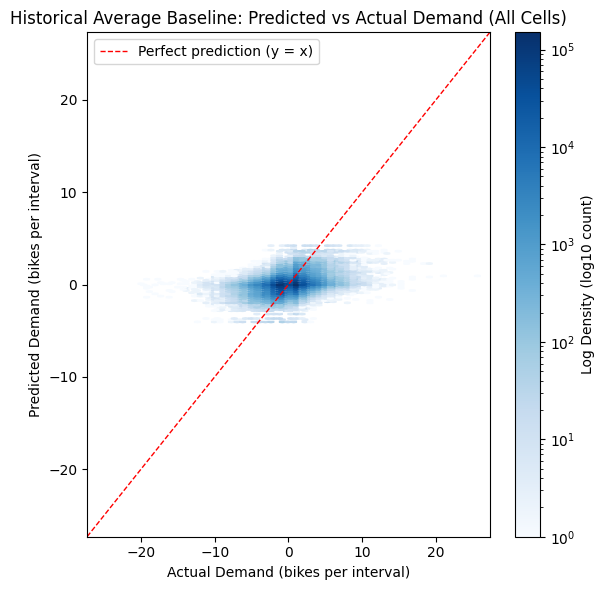

In [ ]:
import os
import matplotlib.pyplot as plt

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 6))

hb = ax.hexbin(targets, preds, gridsize=60, bins='log', cmap='Blues', mincnt=1)

lim = max(abs(targets).max(), abs(preds).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1, label='Perfect prediction (y = x)')

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_xlabel('Actual Demand (bikes per interval)')
ax.set_ylabel('Predicted Demand (bikes per interval)')
ax.set_title('Historical Average Baseline: Predicted vs Actual Demand (All Cells)')
ax.legend()

plt.colorbar(hb, ax=ax, label='Log Density (log10 count)')

plt.tight_layout()

save_path = os.path.join(out_dir, "pred_vs_actual_baseline.png")
plt.savefig(save_path, dpi=120, bbox_inches='tight')

print(f"Saved plot to {save_path}")
plt.show()

Saved plot to outputs/residuals_dist_baseline.png


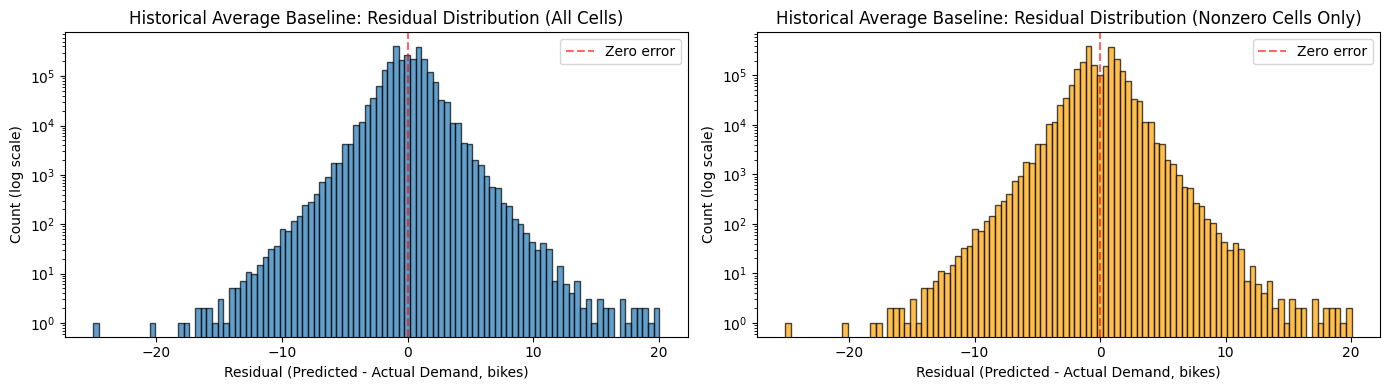

In [ ]:
import os
import matplotlib.pyplot as plt

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

residuals = preds - targets
nz_mask = targets != 0

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ---- All cells ----
axes[0].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Residual (Predicted - Actual Demand, bikes)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Historical Average Baseline: Residual Distribution (All Cells)')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.6, label='Zero error')
axes[0].set_yscale('log')
axes[0].legend()

# ---- Nonzero only ----
axes[1].hist(residuals[nz_mask], bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Residual (Predicted - Actual Demand, bikes)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Historical Average Baseline: Residual Distribution (Nonzero Cells Only)')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.6, label='Zero error')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()

save_path = os.path.join(out_dir, "residuals_dist_baseline.png")
plt.savefig(save_path, dpi=120, bbox_inches='tight')

print(f"Saved plot to {save_path}")
plt.show()